# Анализ экспериментов музейного комплекса

Загрузка и визуализация результатов серии экспериментов из `results.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('results.csv')
print(f'Загружено {len(df)} экспериментов')
df.head()

Загружено 162 экспериментов


,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,numVisitors,maxDays,totalVisits,totalHotelStays,totalRefusals,...,finalWear,finalAttractiveness,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview
0,10,3,20,30,5000,65,365,997,308,22728,...,37.38,21.52,-25820.0,35.04,35.04,39.05,39.05,39.05,39.05,18.51
1,10,3,20,30,5000,65,365,910,238,22815,...,47.02,16.36,-29660.0,36.35,36.35,39.05,39.05,39.05,39.05,12.38
2,10,3,20,30,5000,65,365,1020,306,22705,...,33.42,22.31,-25420.0,34.71,34.71,39.05,39.05,39.05,39.05,20.53
3,10,3,20,50,5000,65,365,1023,302,22702,...,41.97,17.97,-19440.0,34.67,34.67,39.05,39.05,39.05,39.05,14.24
4,10,3,20,50,5000,65,365,1002,312,22723,...,34.92,17.31,-19360.0,34.97,34.97,39.05,39.05,39.05,39.05,13.12


In [2]:
df.describe().round(2)

,museumCapacity,hotelCapacity,ticketPrice,hotelPrice,monthlyExpenditures,numVisitors,maxDays,totalVisits,totalHotelStays,totalRefusals,...,finalWear,finalAttractiveness,finalBudget,finalMobileNetwork,finalPaymentSystem,finalTransportAccess,finalInternetQuality,finalNavigationAccess,finalServiceAvailability,finalAvgReview
count,162.0,162.00,162.00,162.00,162.0,162.0,162.0,162.00,162.00,162.00,...,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.00,162.00
mean,15.0,5.00,33.33,40.00,5000.0,65.0,365.0,1693.12,480.88,22031.88,...,33.89,33.05,23338.46,48.24,48.24,50.59,50.53,50.53,50.53,32.89
std,4.1,1.64,12.51,10.03,0.0,0.0,0.0,840.23,222.44,840.23,...,10.03,17.97,54960.83,12.66,12.66,14.60,14.63,14.63,14.63,18.99
min,10.0,3.00,20.00,30.00,5000.0,65.0,365.0,910.00,238.00,20518.00,...,19.11,13.01,-29660.00,33.98,33.98,39.05,39.05,39.05,39.05,6.71
25%,10.0,3.00,20.00,30.00,5000.0,65.0,365.0,1042.75,307.25,21249.50,...,22.75,18.41,-17865.00,38.90,38.90,39.05,39.05,39.05,39.05,17.48
50%,15.0,5.00,30.00,40.00,5000.0,65.0,365.0,1117.00,334.00,22608.00,...,36.45,21.70,-10165.00,41.57,41.57,39.05,39.05,39.05,39.05,23.10
75%,20.0,7.00,50.00,50.00,5000.0,65.0,365.0,2475.50,689.75,22682.25,...,42.34,55.14,84030.00,62.28,62.28,69.05,69.05,69.05,69.05,54.96
max,20.0,7.00,50.00,50.00,5000.0,65.0,365.0,3207.00,933.00,22815.00,...,53.40,59.14,127910.00,68.03,68.03,69.05,69.05,69.05,69.05,64.88


## 1. Доля экспериментов с положительным бюджетом

Положительный бюджет: 62/162 (38.3%)
Отрицательный бюджет: 100/162 (61.7%)
Средний итоговый бюджет: 23338
Медиана итогового бюджета: -10165


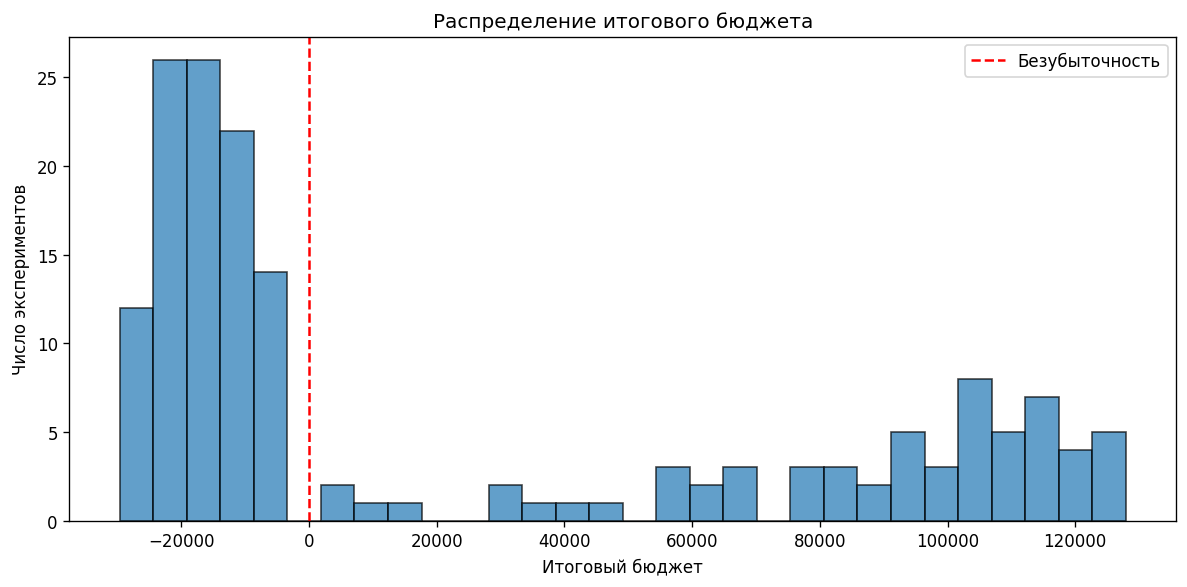

In [3]:
positive = (df['finalBudget'] > 0).sum()
total = len(df)
print(f'Положительный бюджет: {positive}/{total} ({positive/total*100:.1f}%)')
print(f'Отрицательный бюджет: {total - positive}/{total} ({(total-positive)/total*100:.1f}%)')
print(f'Средний итоговый бюджет: {df["finalBudget"].mean():.0f}')
print(f'Медиана итогового бюджета: {df["finalBudget"].median():.0f}')

fig, ax = plt.subplots()
ax.hist(df['finalBudget'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Безубыточность')
ax.set_xlabel('Итоговый бюджет')
ax.set_ylabel('Число экспериментов')
ax.set_title('Распределение итогового бюджета')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Влияние цены билета на бюджет и посещаемость

             avgBudget  avgVisits  avgReview  positivePct
ticketPrice                                              
20            -21096.3     1064.3       18.6          0.0
30             -6531.3     1211.8       24.0         14.8
50             97643.0     2803.3       56.1        100.0


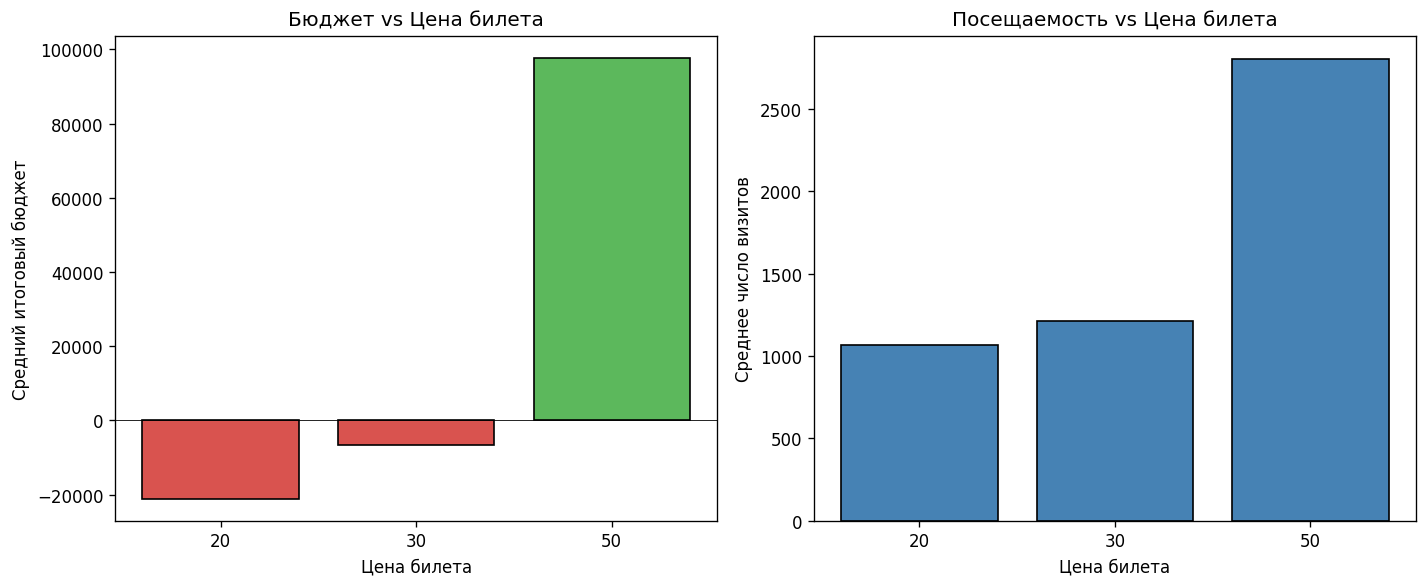

In [4]:
grouped = df.groupby('ticketPrice').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgReview=('finalAvgReview', 'mean'),
    positivePct=('finalBudget', lambda x: (x > 0).mean() * 100)
).round(1)
print(grouped)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(grouped.index.astype(str), grouped['avgBudget'], color=['#d9534f' if v < 0 else '#5cb85c' for v in grouped['avgBudget']], edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Цена билета')
axes[0].set_ylabel('Средний итоговый бюджет')
axes[0].set_title('Бюджет vs Цена билета')

axes[1].bar(grouped.index.astype(str), grouped['avgVisits'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Цена билета')
axes[1].set_ylabel('Среднее число визитов')
axes[1].set_title('Посещаемость vs Цена билета')

plt.tight_layout()
plt.show()

## 3. Влияние вместимости музея на доход и отказы

                avgBudget  avgVisits  avgRefusals  avgWear
museumCapacity                                            
10                12725.9     1486.1      22238.9     33.5
15                25323.3     1709.0      22016.0     34.8
20                31966.1     1884.3      21840.7     33.4


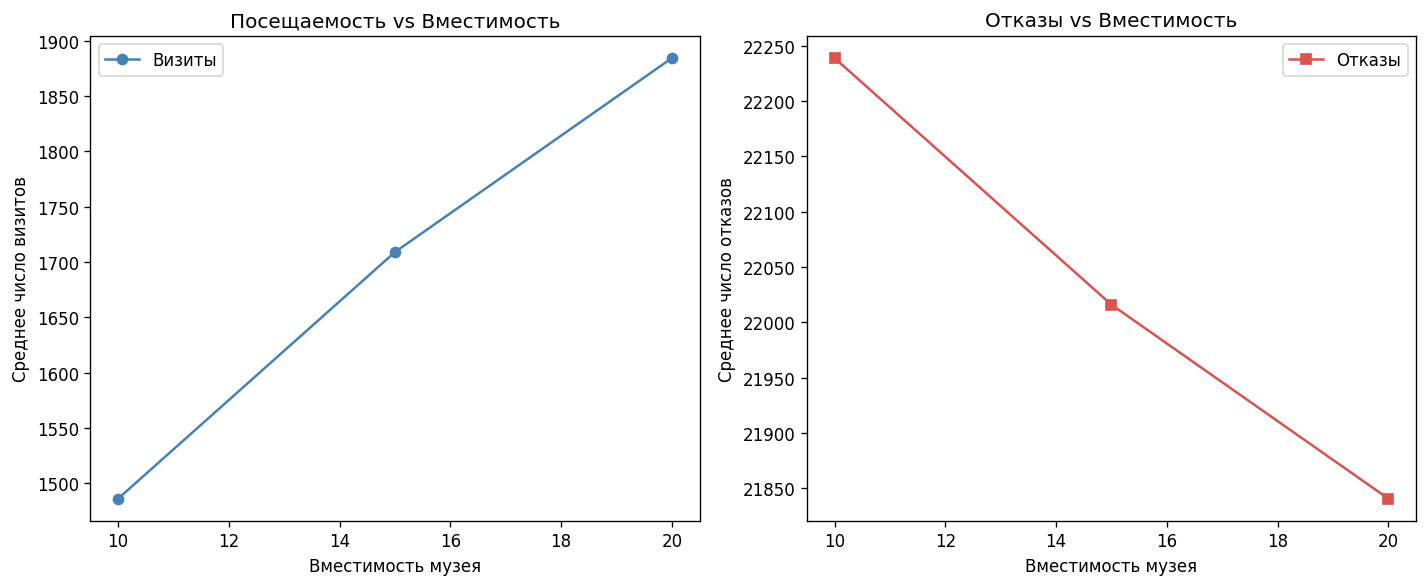

In [5]:
grouped_cap = df.groupby('museumCapacity').agg(
    avgBudget=('finalBudget', 'mean'),
    avgVisits=('totalVisits', 'mean'),
    avgRefusals=('totalRefusals', 'mean'),
    avgWear=('finalWear', 'mean')
).round(1)
print(grouped_cap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(grouped_cap.index, grouped_cap['avgVisits'], 'o-', label='Визиты', color='steelblue')
axes[0].set_xlabel('Вместимость музея')
axes[0].set_ylabel('Среднее число визитов')
axes[0].set_title('Посещаемость vs Вместимость')
axes[0].legend()

axes[1].plot(grouped_cap.index, grouped_cap['avgRefusals'], 's-', label='Отказы', color='#d9534f')
axes[1].set_xlabel('Вместимость музея')
axes[1].set_ylabel('Среднее число отказов')
axes[1].set_title('Отказы vs Вместимость')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Матрица корреляций ключевых метрик

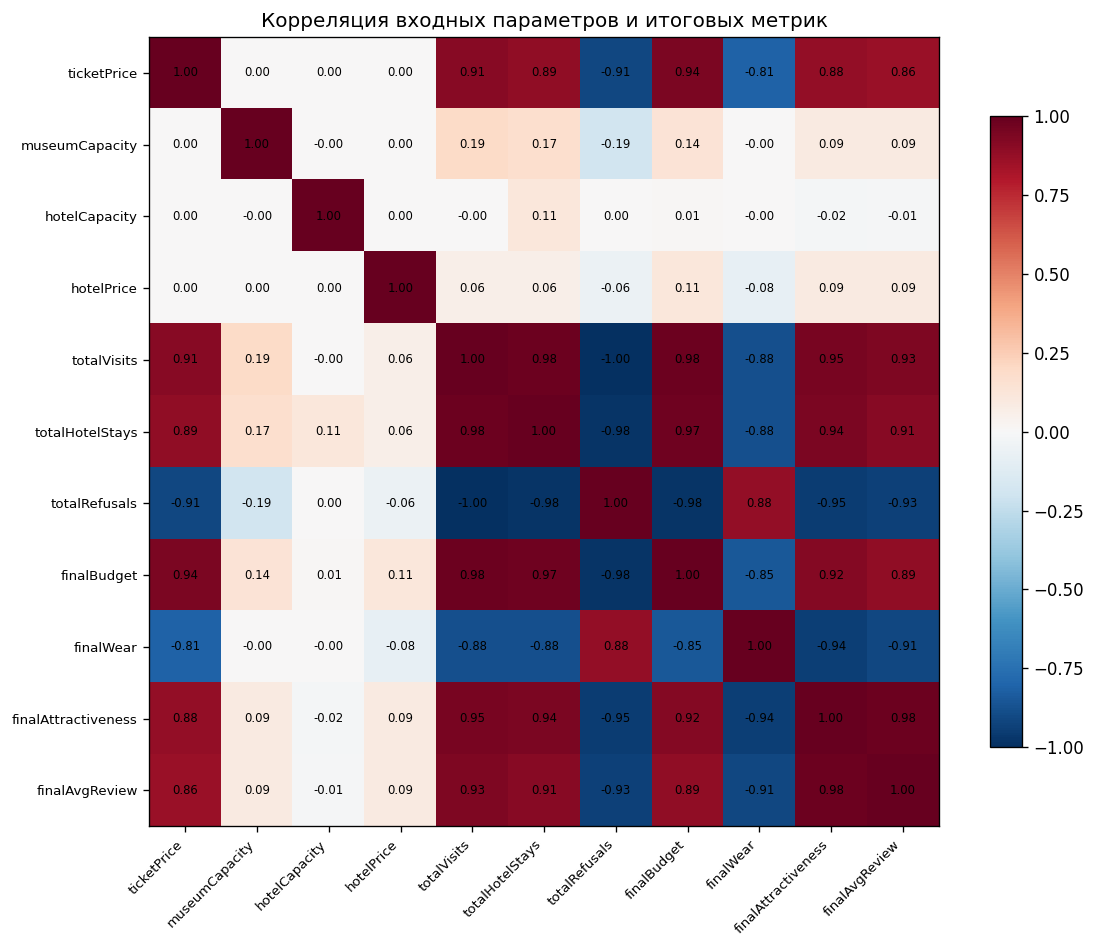

In [6]:
cols = ['ticketPrice', 'museumCapacity', 'hotelCapacity', 'hotelPrice',
        'totalVisits', 'totalHotelStays', 'totalRefusals',
        'finalBudget', 'finalWear', 'finalAttractiveness', 'finalAvgReview']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Корреляция входных параметров и итоговых метрик')
plt.tight_layout()
plt.show()

## 5. Scatter: Визиты vs Итоговый бюджет (по цене билета)

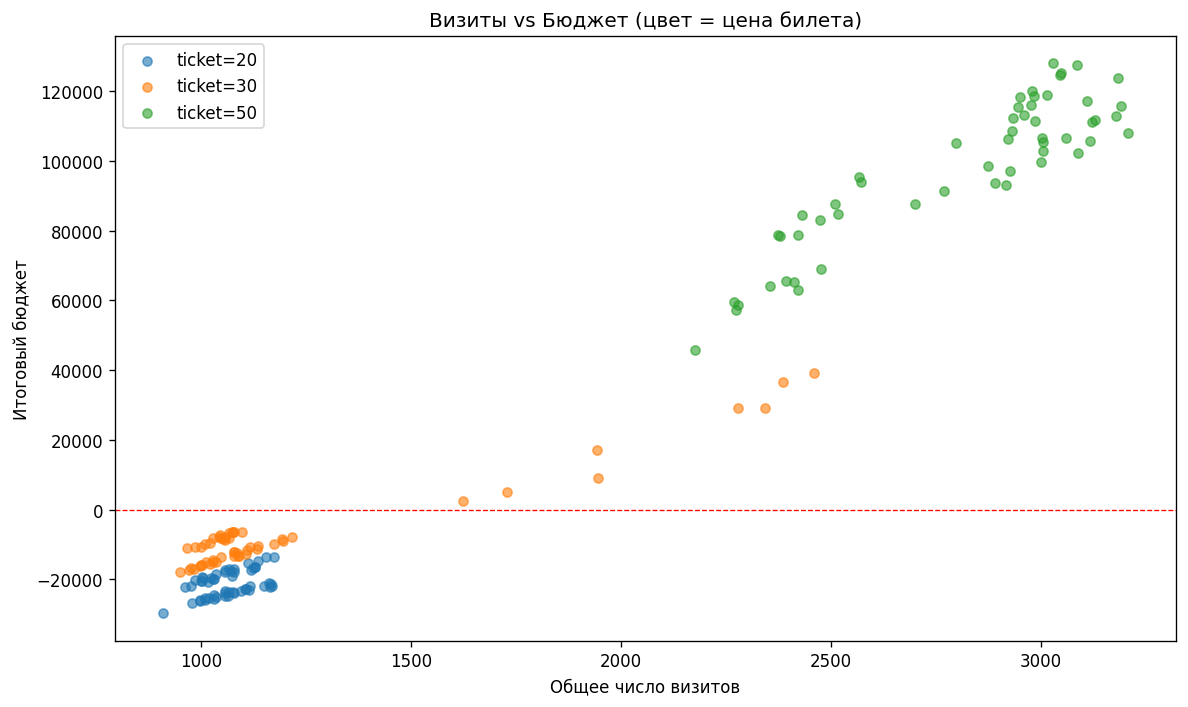

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for price, grp in df.groupby('ticketPrice'):
    ax.scatter(grp['totalVisits'], grp['finalBudget'], label=f'ticket={price}', alpha=0.6, s=30)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Общее число визитов')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Визиты vs Бюджет (цвет = цена билета)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Boxplot: итоговый бюджет по комбинации (ticketPrice x hotelPrice)

/var/folders/4j/sxql7z6j007czwcf5zkcl4gh0000gn/T/ipykernel_28791/4188328468.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)


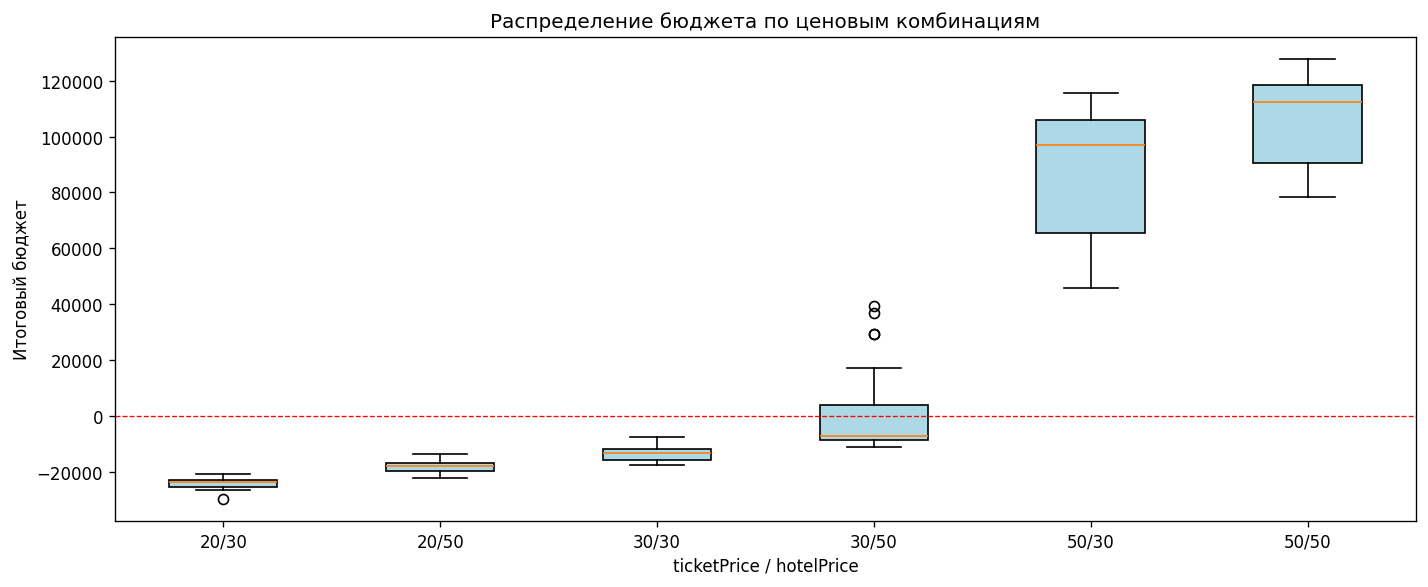

In [8]:
df['price_combo'] = df['ticketPrice'].astype(str) + '/' + df['hotelPrice'].astype(str)
combos_sorted = sorted(df['price_combo'].unique(), key=lambda x: (int(x.split('/')[0]), int(x.split('/')[1])))

fig, ax = plt.subplots(figsize=(12, 5))
data_groups = [df[df['price_combo'] == c]['finalBudget'].values for c in combos_sorted]
bp = ax.boxplot(data_groups, labels=combos_sorted, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('ticketPrice / hotelPrice')
ax.set_ylabel('Итоговый бюджет')
ax.set_title('Распределение бюджета по ценовым комбинациям')
plt.tight_layout()
plt.show()

df.drop(columns=['price_combo'], inplace=True)